Process data extracted from IFRC reports

In [1]:
import pandas as pd
import json
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re

In [2]:
file_path = './Data/all_ifrc_reports_info_unnested_processed.json'

# Open and read the JSON file
with open(file_path, 'r') as json_file:
    all_ifrc_reports_info_unnested = json.load(json_file)

In [3]:
all_ifrc_reports_info_unnested[0].keys()

dict_keys(['reportName', 'disasterType', 'date', 'reportLink', 'location', 'appealCode', 'appealType', 'pdfDownloaded', 'text', 'disasterTypeFlag', 'disasterTypeReclassified'])

In [4]:
list_disasters = []

for element in all_ifrc_reports_info_unnested:
    if (element['disasterTypeReclassified']) and (element['pdfDownloaded'] == 1):
        list_disasters.append(element['disasterTypeReclassified'])

In [5]:
Counter(list_disasters)

Counter({'Other': 804,
         'Flood': 757,
         'Earthquake': 348,
         'Population Movement': 281,
         'Cyclone': 233,
         'Epidemic': 214,
         'Other disaster': 176,
         'Annual appeal': 157,
         'Drought': 118,
         'Food Insecurity': 100,
         'Storm': 47,
         'Civil Unrest': 47,
         'Volcano': 38,
         'Complex Emergency': 33,
         'Fire': 26,
         'Humanitarian Crisis': 24,
         'Coldwave': 21,
         'Hurricane': 21,
         'Unified Plan': 13,
         'Wildfire': 12,
         'Mass movement': 11,
         'Flood, Mass movement': 10,
         'Cyclone, Flood': 9,
         'Flood, Storm': 8,
         'Heatwave': 5,
         'Drought, Other disaster': 5,
         'Transport Accident': 4,
         'Epidemic, All other disaster and emergencies': 4,
         'Population Movement, All other disaster and emergencies': 4,
         'Tidal Wave': 4,
         'Cholera': 3,
         'Earthquake, Tsunami': 3,
         

Filtering natural hazards

In [6]:
nat_hazard_classes = ['Flood', 'Earthquake', 'Cyclone', 'Drought', 'Storm', 'Fire', 'Hurricane', 'Volcanic Eruption', 'Coldwave', 'Wildfire', 'Fire', 'Mass movement', 'Tsunami', 'Typhoon', 'Tornado']

In [7]:
compound_nat_hazard_classes = ['Flood, Mass movement', 'Cyclone, Flood', 'Flood, Storm', 'Drought, Other disaster',
                               'Earthquake, Tsunami', 'Drought, Flood', 'Drought, Flood, Other disaster',
                               'Drought, Flood, Population Movement, Other disaster',
                               'Earthquake, Flood', 'Heatwave, Fire', 'Landslide, Flood', 'Coldwave, Other disaster',
                               'Drought, Food Insecurity', 'Landslide, Flood, Other disaster', 'Flood, Other disaster',
                               'Coldwave, Earthquake, Other disaster', 'Cyclone, Storm',
                               'Coldwave, Flood', 'Landslide, Cyclone, Flood', 'Epidemic, Flood',
                               'Drought, Epidemic, Earthquake, Cyclone, Flood, Other disaster',
                               'Drought, Epidemic, Flood, Population Movement',
                               'Drought, Population Movement, Other disaster',
                               'Cyclone, Other disaster',
                               'Epidemic, Flood, Population Movement, Other disaster',
                               'Drought, Epidemic, Other disaster',
                               'Drought, Epidemic, Flood, Population Movement, Other disaster',
                               'Flood, Population Movement, Other disaster',
                               'Drought, Epidemic, Earthquake, Cyclone, Flood, Civil Unrest, Complex Emergency, Population Movement',
                               'Coldwave, Heatwave, Drought, Epidemic, Insect Infestation, Earthquake, Landslide, Tsunami, Volcanic Eruption, Cyclone, Storm, Flood, Transport Accident, Nuclear Emergency, Chemical Emergency, Civil Unrest, Complex Emergency, Fire, Population Movement, Other disaster']

In [8]:
other_hazard_classes = ['Epidemic', 'Population Movement', 'Other disaster', 'Food Insecurity', 'Civil Unrest', 'Complex Emergency', 'Insect Infestation', 'Transport Accident', 'Nuclear Emergency', 'Chemical Emergency']

Identifying single events and compounding events

In [9]:
ifrc_reports_natural_hazards = []
count_multi = 0
count_single = 0
for element in all_ifrc_reports_info_unnested:
    if (element['disasterTypeReclassified'] in nat_hazard_classes) and ('text' in element):
        ifrc_reports_natural_hazards.append(element)
        element['multiHazard'] = 0
        count_single += 1
    if (element['disasterTypeReclassified'] in compound_nat_hazard_classes) and ('text' in element):
        ifrc_reports_natural_hazards.append(element)
        element['multiHazard'] = 1
        count_multi += 1

In [10]:
count_multi

66

In [11]:
count_single

1598

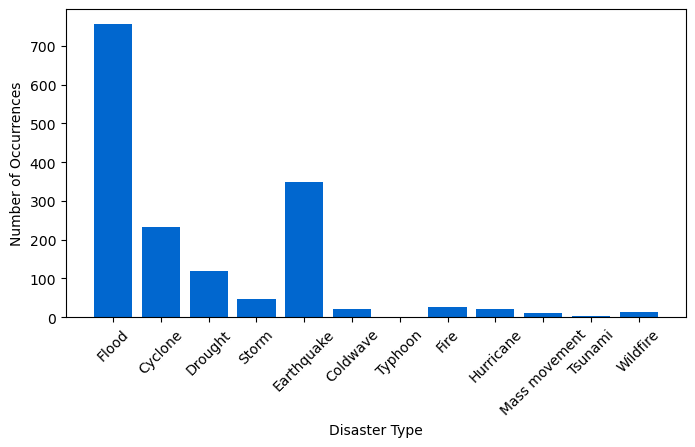

In [12]:
# Count the occurrences of each class in the 'disasterTypeReclassified' key
disaster_types = [item['disasterTypeReclassified'] for item in ifrc_reports_natural_hazards if item['disasterTypeReclassified'] in nat_hazard_classes]
disaster_counts = Counter(disaster_types)

plt.figure(figsize=(8, 4))
plt.bar(disaster_counts.keys(), disaster_counts.values(), color='#0167cf')
plt.gcf().set_facecolor('none')
plt.xlabel('Disaster Type')
plt.ylabel('Number of Occurrences')
plt.title('')
plt.xticks(rotation=45)
plt.show()

In [13]:
ifrc_reports_natural_hazards_copy = ifrc_reports_natural_hazards.copy()

In [14]:
list_compound_hazards = []
for item in ifrc_reports_natural_hazards_copy:
    item['disasterTypeReclassified'] = item['disasterTypeReclassified'].split(', ')
    if item['multiHazard'] == 1:
        list_compound_hazards.append(item['disasterTypeReclassified'])

In [65]:
list_compound_hazards

[['Heatwave', 'Fire'],
 ['Landslide', 'Flood'],
 ['Coldwave', 'Other disaster'],
 ['Drought', 'Food Insecurity'],
 ['Landslide', 'Flood', 'Other disaster'],
 ['Flood', 'Other disaster'],
 ['Coldwave', 'Earthquake', 'Other disaster'],
 ['Cyclone', 'Storm'],
 ['Earthquake', 'Tsunami'],
 ['Cyclone', 'Flood'],
 ['Earthquake', 'Tsunami'],
 ['Cyclone', 'Flood'],
 ['Cyclone', 'Flood'],
 ['Earthquake', 'Tsunami'],
 ['Coldwave',
  'Heatwave',
  'Drought',
  'Epidemic',
  'Insect Infestation',
  'Earthquake',
  'Landslide',
  'Tsunami',
  'Volcanic Eruption',
  'Cyclone',
  'Storm',
  'Flood',
  'Transport Accident',
  'Nuclear Emergency',
  'Chemical Emergency',
  'Civil Unrest',
  'Complex Emergency',
  'Fire',
  'Population Movement',
  'Other disaster'],
 ['Coldwave',
  'Heatwave',
  'Drought',
  'Epidemic',
  'Insect Infestation',
  'Earthquake',
  'Landslide',
  'Tsunami',
  'Volcanic Eruption',
  'Cyclone',
  'Storm',
  'Flood',
  'Transport Accident',
  'Nuclear Emergency',
  'Chemical E

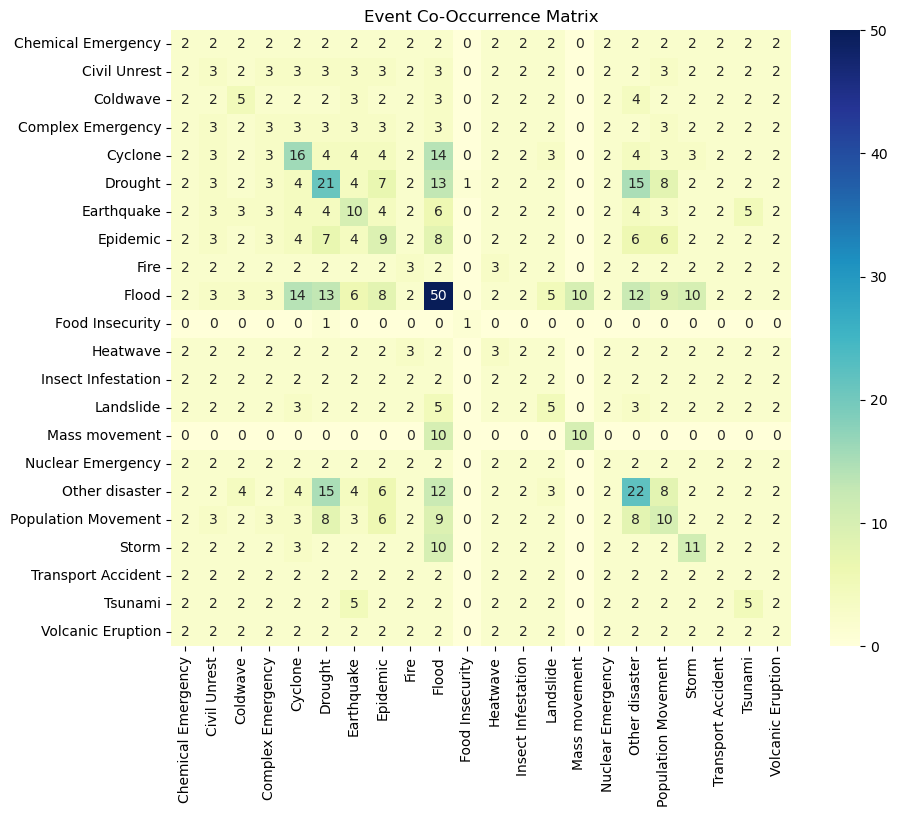

In [15]:
# Step 1: Identify unique events
unique_events = set()
for event_list in list_compound_hazards:
    unique_events.update(event_list)
unique_events = sorted(unique_events)

# Step 2: Create the co-occurrence matrix
co_occurrence_matrix = pd.DataFrame(0, index=unique_events, columns=unique_events)

for event_list in list_compound_hazards:
    for i in range(len(event_list)):
        for j in range(i, len(event_list)):
            co_occurrence_matrix.loc[event_list[i], event_list[j]] += 1
            if i != j:
                co_occurrence_matrix.loc[event_list[j], event_list[i]] += 1

# Step 3: Plot the matrix
plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence_matrix, annot=True, cmap="YlGnBu", fmt="d")
plt.title("Event Co-Occurrence Matrix")
plt.show()

Text preprocessing

In [16]:
# Function to clean the text
def clean_text(text):
    # Remove hyperlinks
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove special characters except for basic punctuation (e.g., commas, periods)
    #text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text)
    # Remove newlines
    text = text.replace('\n', ' ')
    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [17]:
for item in ifrc_reports_natural_hazards:
    item['text_processed'] = clean_text(item['text'])

Tokenize reports into sentences

In [18]:
import nltk
nltk.download('punkt')  # Download the sentence tokenizer

from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [19]:
# Iterate over each dictionary in the list
for item in ifrc_reports_natural_hazards:
    # Tokenize the 'text' into sentences
    sentences = sent_tokenize(item['text_processed'])
    # Append tokenized sentences back into the dictionary
    item['sentences'] = sentences

Filter reports to create toy dataset

In [21]:
filtered_reports_toy = [
    disaster_report for disaster_report in ifrc_reports_natural_hazards
    if (disaster_report['appealType'] in ['Operations Update', 'DREF Operation', 'DREF Operation Final Report', 'DREF Operation Update'])
    and (disaster_report['disasterType'] in ['Drought'])
]

In [102]:
#keys_to_remove = ['pdfDownloaded', 'disasterTypeReclassified', 'multiHazard', 'text_processed', 'sentences', 'sentencesHazards', 'hazard_list']
#
#for report in filtered_reports_toy:
#    for key in keys_to_remove:
#        report.pop(key, None)

In [22]:
json_filename = 'data/ifrc_reports_toy_data.json'
with open(json_filename, 'w') as f:
    json.dump(filtered_reports_toy, f, indent=4)

Filter reports

In [23]:
filtered_reports = [
    disaster_report for disaster_report in ifrc_reports_natural_hazards
    if disaster_report['appealType'] in ['Operations Update', 'DREF Operation', 'DREF Operation Final Report', 'DREF Operation Update']
]

In [24]:
#check for not reclassified
no_reclass = []
for item in filtered_reports[:]:
    if 'disasterTypeReclassified' not in item.keys():
       no_reclass.append(item)

In [40]:
nat_hazard_classes

['Flood',
 'Earthquake',
 'Cyclone',
 'Drought',
 'Storm',
 'Fire',
 'Hurricane',
 'Volcanic Eruption',
 'Coldwave',
 'Wildfire',
 'Fire',
 'Mass movement',
 'Tsunami',
 'Typhoon',
 'Tornado']

In [43]:
item['disasterTypeReclassified'][0]

'Earthquake'

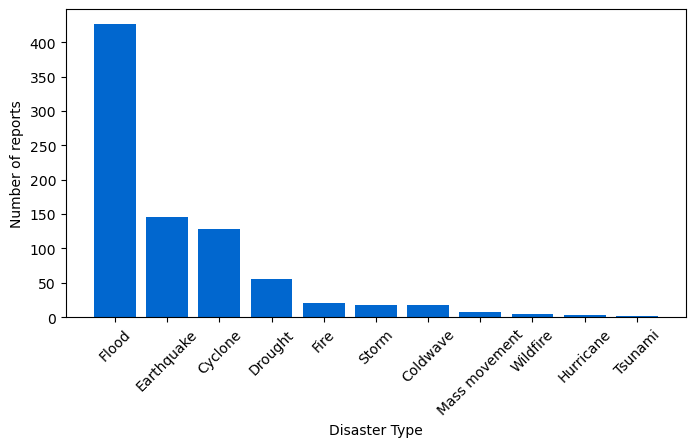

In [44]:
# Count the occurrences of each class in the 'disasterTypeReclassified' key
disaster_types = [item['disasterTypeReclassified'][0] for item in filtered_reports if item['disasterTypeReclassified'][0] in nat_hazard_classes]
disaster_counts = Counter(disaster_types)

# Sort the disaster_counts dictionary by values in descending order
sorted_disaster_counts = dict(sorted(disaster_counts.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(8, 4))
plt.bar(sorted_disaster_counts.keys(), sorted_disaster_counts.values(), color='#0167cf')
plt.gcf().set_facecolor('none')
plt.gca().patch.set_alpha(0)
plt.xlabel('Disaster Type')
plt.ylabel('Number of reports')
plt.title('')
plt.xticks(rotation=45)
plt.show()

Plot frequency in world map

In [31]:
# Add the ISO code to each dict in the list

import pycountry

for report in filtered_reports:
    country_name = report.get("location")
    try:
        # Lookup the ISO code using pycountry
        country = pycountry.countries.get(name=country_name)
        if country:
            report["iso_code"] = country.alpha_3  # Adds the ISO 3166-1 Alpha-3 code
        else:
            report["iso_code"] = "Unknown"
    except KeyError:
        report["iso_code"] = "Unknown"


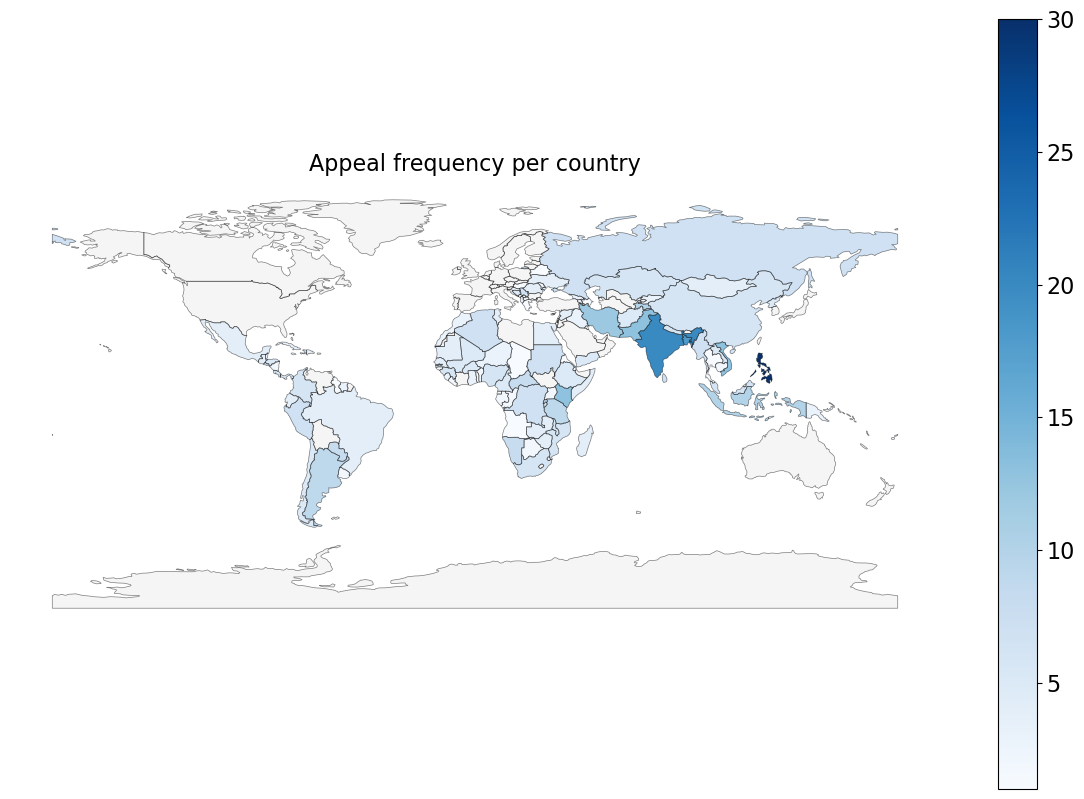

In [32]:
import pycountry
import geopandas as gpd
from collections import defaultdict

# Step 1: Map country names to ISO codes and count unique appeal codes per country
country_appeal_count = defaultdict(set)

for report in filtered_reports:
    country_name = report.get("location")
    appeal_code = report.get("appealCode")

    try:
        country = pycountry.countries.get(name=country_name)
        if country:
            iso_code = country.alpha_3  # ISO 3166-1 Alpha-3 code
            country_appeal_count[iso_code].add(appeal_code)  # Add unique appealCode
    except KeyError:
        continue

# Convert sets of appealCodes to the count of unique codes per country
country_appeal_count = {iso: len(codes) for iso, codes in country_appeal_count.items()}

# Step 2: Create a DataFrame from the counts
df = pd.DataFrame(list(country_appeal_count.items()), columns=["iso_code", "appeal_count"])

shapefile_path = "data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
world = gpd.read_file(shapefile_path)

# Merge the world map with the appeal count DataFrame based on the ISO codes
world = world.merge(df, how="left", left_on="ADM0_A3", right_on="iso_code")

# Step 3: Plot the static choropleth map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Transparent country boundaries
world.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.5)  # Semi-transparent boundaries

# Plot the map with color based on the appeal_count column
world_plot = world.plot(column="appeal_count", ax=ax, legend=True, cmap="Blues", missing_kwds={
    "color": "whitesmoke",
    "label": "No data"
})

# Reduce the size of the colorbar
cbar = world_plot.get_figure().get_axes()[1]  # Colorbar is usually on the second axis
#cbar.set_aspect(10)  # Reduce the colorbar's size vertically
cbar.tick_params(labelsize=16)  # Smaller font size for ticks

# Set plot title and labels
ax.set_title("Appeal frequency per country", fontsize=16)
ax.set_axis_off()  # Hide axis

# Save the plot with a transparent background
plt.savefig("world_map_frequency.png", bbox_inches='tight', transparent=True)

# Show the plot
plt.show()

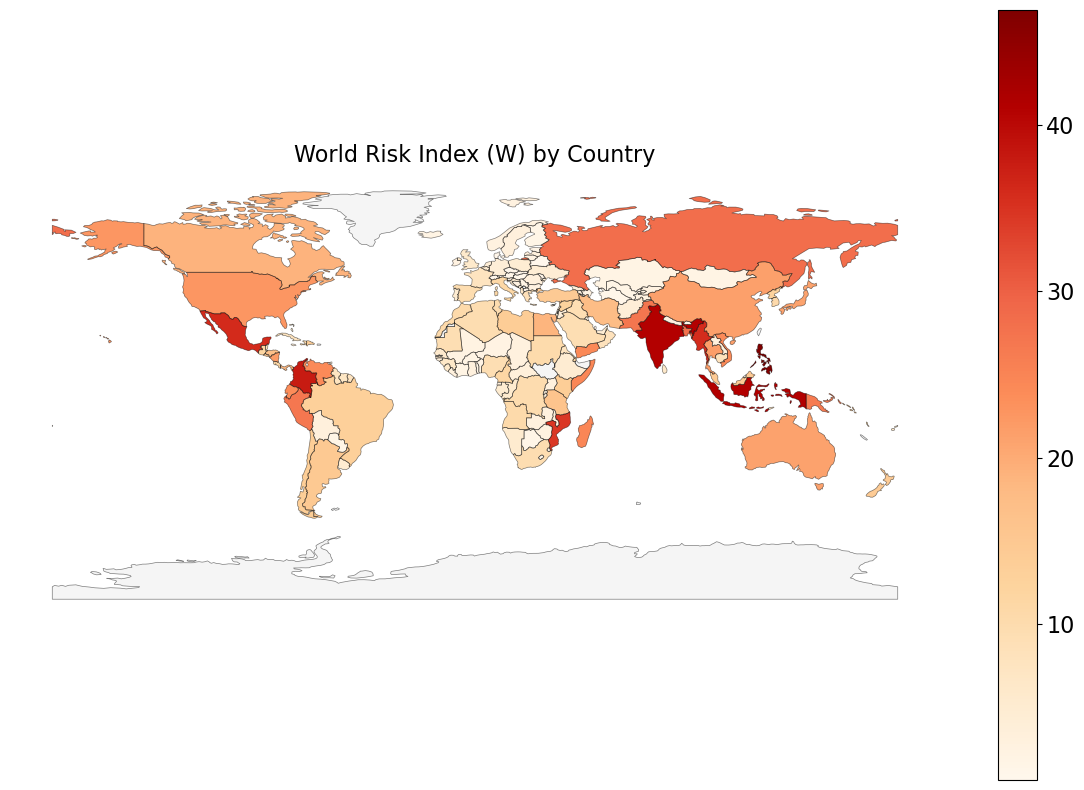

In [33]:
df_world_risk_index = pd.read_csv("data/worldriskindex-datasets/worldriskindex-2024.csv")
world = gpd.read_file(shapefile_path)

# Step 2: Merge the world map with the risk index DataFrame based on ISO3 codes
world = world.merge(df_world_risk_index, how="left", left_on="ADM0_A3", right_on="ISO3.Code")

# Step 3: Plot the static choropleth map with transparent background
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Transparent country boundaries
world.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.5)  # Semi-transparent boundaries

# Plot the map with color based on the 'W' column
world_plot = world.plot(column="W", ax=ax, legend=True, cmap="OrRd", missing_kwds={
    "color": "whitesmoke",
    "label": "No data"
})

# Reduce the size of the colorbar
cbar = world_plot.get_figure().get_axes()[1]  # Colorbar is usually on the second axis
#cbar.set_aspect(30)  # Shrink the colorbar's size vertically
cbar.tick_params(labelsize=16)  # Smaller font size for ticks

# Set plot title and labels
ax.set_title("World Risk Index (W) by Country", fontsize=16)
ax.set_axis_off()  # Hide axis

# Save the plot with a transparent background
plt.savefig("world_risk_index_W.png", bbox_inches='tight', transparent=True)

# Show the plot
plt.show()

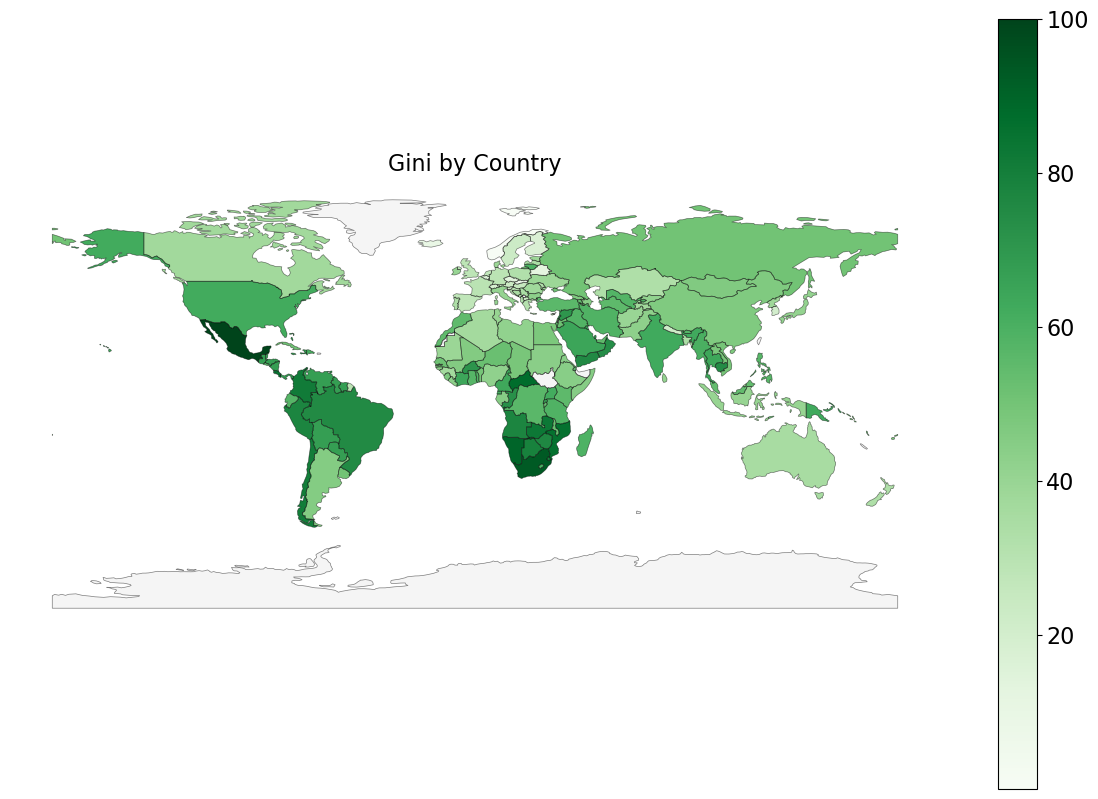

In [34]:
df_world_risk_index = pd.read_csv("data/worldriskindex-datasets/worldriskindex-2024.csv")
world = gpd.read_file(shapefile_path)

# Step 2: Merge the world map with the risk index DataFrame based on ISO3 codes
world = world.merge(df_world_risk_index, how="left", left_on="ADM0_A3", right_on="ISO3.Code")

# Step 3: Plot the static choropleth map with transparent background
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Transparent country boundaries
world.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.5)  # Semi-transparent boundaries

# Plot the map with color based on the 'W' column
world_plot = world.plot(column="SI_09a_Norm", ax=ax, legend=True, cmap="Greens", missing_kwds={
    "color": "whitesmoke",
    "label": "No data"
})

# Reduce the size of the colorbar
cbar = world_plot.get_figure().get_axes()[1]  # Colorbar is usually on the second axis
#cbar.set_aspect(30)  # Shrink the colorbar's size vertically
cbar.tick_params(labelsize=16)  # Smaller font size for ticks

# Set plot title and labels
ax.set_title("Gini by Country", fontsize=16)
ax.set_axis_off()  # Hide axis

# Save the plot with a transparent background
plt.savefig("world_gini.png", bbox_inches='tight', transparent=True)

# Show the plot
plt.show()

Extract all sentences mentioning hazards

In [35]:
emdat_df = pd.read_excel("./Data/public_emdat_incl_hist_2024-09-09.xlsx")
emdat_df_filtered = emdat_df.copy()

In [49]:
emdat_df_filtered = emdat_df_filtered[emdat_df_filtered['Disaster Group'].isin(['Natural'])]
emdat_df_filtered = emdat_df_filtered[emdat_df_filtered['Disaster Subgroup'].isin(['Meteorological', 'Hydrological', 'Climatological'])]

In [52]:
emdat_df_filtered[emdat_df_filtered['Disaster Type']=='Storm']['Disaster Subtype'].unique()

array(['Tropical cyclone', 'Tornado', 'Hail', 'Storm (General)',
       'Severe weather', 'Blizzard/Winter storm',
       'Lightning/Thunderstorms', 'Sand/Dust storm',
       'Extra-tropical storm', 'Storm surge', 'Derecho'], dtype=object)

In [ ]:
# classify hazards as tropical cyclone and other storms separately
Tropical_cyclone = ['Hurricane', 'Tropical Cyclone', 'Typhoon']
storm_other = ['Tornado', 'Hail', 'Storm (General)',
       'Severe weather', 'Blizzard/Winter storm',
       'Lightning/Thunderstorms', 'Sand/Dust storm',
       'Extra-tropical storm', 'Storm surge', 'Derecho']

In [135]:
def emdat_filter_haz(df):
    df = df[df['Disaster Group'].isin(['Natural'])]
    df = df[df['Disaster Group'].isin(['Natural'])]
emdat_df

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,Entry Date,Last Update
0,1900-0003-USA,Yes,nat-met-sto-tro,Natural,Meteorological,Storm,Tropical cyclone,NaN,NaN,USA,...,NaN,NaN,NaN,NaN,30000.0,1098720.0,2.730451,NaN,2004-10-18,2023-10-17
1,1900-0005-USA,Yes,tec-ind-fir-fir,Technological,Industrial accident,Fire (Industrial),Fire (Industrial),NaN,NaN,USA,...,NaN,NaN,NaN,NaN,NaN,NaN,2.730451,NaN,2003-07-01,2023-09-25
2,1900-0006-JAM,Yes,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,JAM,...,NaN,NaN,NaN,NaN,NaN,NaN,2.730451,NaN,2003-07-01,2023-09-25
3,1900-0007-JAM,Yes,nat-bio-epi-vir,Natural,Biological,Epidemic,Viral disease,NaN,Gastroenteritis,JAM,...,NaN,NaN,NaN,NaN,NaN,NaN,2.730451,NaN,2003-07-01,2023-09-25
4,1900-0008-JPN,Yes,nat-geo-vol-ash,Natural,Geophysical,Volcanic activity,Ash fall,NaN,NaN,JPN,...,NaN,NaN,NaN,NaN,NaN,NaN,2.730451,NaN,2003-07-01,2023-09-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26716,2024-9197-ZWE,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,GLIDE:DR-2024-000066|GLIDE:DR-2024-000069,NaN,ZWE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-05,2024-08-12
26717,2024-9277-VNM,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,VNM,...,NaN,NaN,NaN,NaN,10000.0,NaN,NaN,NaN,2024-05-03,2024-08-12
26718,2024-9338-NAM,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,GLIDE:DR-2024-000094,NaN,NAM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-06-07,2024-08-12
26719,2024-9381-GRD,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,GLIDE:DR-2024-000079,NaN,GRD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-06-14,2024-08-12


#does the same as check_hazard_type_keyword
def check_hazard_type_keyword(text):
    text = text.lower()
    hazards = []
    if re.search(r"drought.*|dry spell.*", text, re.IGNORECASE):
        hazards.append('Drought')
    if re.search(r"\b(flood|floods|flooding|inundation|inundations|glacial lake outburst)\b", text, re.IGNORECASE):
        hazards.append('Flood')
    if re.search(r"storm.*|superstorm.*|windstorm.*|snowstorm.*|snowfal.*|blizzard.*|derecho.*|winterstorm.*|hail.*|extra tropical storm.*|thunderstorm.*|storm surge.*", text, re.IGNORECASE):
        hazards.append('Storm')
    if re.search(r"tornado.*", text, re.IGNORECASE):
        hazards.append('Tornado')
    #if re.search(r"hurricane.*", text, re.IGNORECASE):
    #    hazards.append('Hurricane')
    if re.search(r"heat wave.*|heatwave.*|heat episode.*|((heat|hot) spell).*|heat stress.*", text, re.IGNORECASE):
        hazards.append('Heatwave')
    if re.search(r"cold wave.*|coldwave.*|severe winter conditions.*|cold spell.*", text, re.IGNORECASE):
        hazards.append('Coldwave')
    if re.search(r"land slide.*|landslide.*|rockfall.*|mudslide.*|mass movement.*", text, re.IGNORECASE):
        hazards.append('Mass movement')
    if re.search(r"earthquake.*", text, re.IGNORECASE):
        hazards.append('Earthquake')
    if re.search(r"cyclone.*|tropical cyclone.*|hurricane.*|typhoon.*", text, re.IGNORECASE):
        hazards.append('Cyclone')
    if re.search(r"volcan.*", text, re.IGNORECASE):
        hazards.append('Volcano')
    if re.search(r"tidal wav.*", text, re.IGNORECASE):
        hazards.append('Tidal Wave')
    if re.search(r"fire.*|forestfire.*|wildfire.*|landfire.*|bushfire.*|forest fire.*|wild fire.*|land fire.*|bush fire.*", text, re.IGNORECASE):
        hazards.append('Wildfire')
    #if re.search(r"humanitarian crisis.*", text, re.IGNORECASE):
    #    hazards.append('Humanitarian Crisis')
    #if re.search(r"food.*|hung.*", text, re.IGNORECASE):
    #    hazards.append('Food Insecurity')
    #if re.search(r"population movement.*|displac.*|pop. movement.*", text, re.IGNORECASE):
    #    hazards.append('Population Movement')
    if len(hazards) == 0:
        return 'None'
    else:
        return hazards#return ', '.join(hazards).split(', ')

for disaster_report in filtered_reports:
    sentences = disaster_report['sentences']
    hazard_list_all_sentences = []
    disaster_report['sentencesHazards'] = []
    for sentence in sentences:
        hazard_list = check_hazard_type_keyword(sentence)
        if hazard_list != 'None':
            if len(hazard_list) > 1:
                disaster_report['sentencesHazards'].append(sentence)
                hazard_list_all_sentences.append(hazard_list)
    disaster_report['hazard_list'] = hazard_list_all_sentences

for element in filtered_reports[3:25]:
    print(element['disasterType'])
    print(element['sentencesHazards'])
    print(element['hazard_list'])
    print('---')

In [ ]:
# Load the SpaCy English model
nlp = spacy.load("en_core_web_sm")

# Function to extract causal relationships from a sentence


def extract_causal_relationships(sentence):
    doc = nlp(sentence)
    causes = []

    # Iterate over the tokens in the sentence
    for token in doc:
        # Check if the token is a verb and in the list of causal verbs
        if token.lemma_ in causal_verbs and token.pos_ == 'VERB':
            # Find the subject (nsubj) and object (dobj) of the verb
            subject = None
            effect = None

            for child in token.children:
                if child.dep_ == 'nsubj':  # Subject (the cause)
                    subject = child.text
                if child.dep_ in ['dobj', 'pobj']:  # Object (the effect)
                    effect = child.text

            # If both subject and object (effect) are found, return the relationship
            if subject and effect:
                causes.append((subject, token.lemma_, effect))

    return causes

In [59]:
# Apply the function to extract causal relationships
for disaster_report in filtered_reports:
    sentences = disaster_report['sentencesHazards']
    for sentence in sentences:
        causal_relations = extract_causal_relationships(sentence)
        if causal_relations:
            #print(f"Sentence: {sentence}")
            for cause in causal_relations:
                if (len(check_hazard_type_keyword(cause[0]))>0) and (len(check_hazard_type_keyword(cause[2]))>0):
                    print(f"Sentence: {sentence}")
                    print(f"  Causal relationship: {cause[0]} -> {cause[2]} (via '{cause[1]}')")
                    print("----")

Sentence: This led to multiple landslides affecting homes and roads, as well as overflowing rivers causing flooding.
  Causal relationship: This -> rivers (via 'lead')
----
Sentence: The low-pressure system has caused landslides, flooding in urban and rural areas, road blockages, river overflows, high-intensity winds, and high tides on the coasts.
  Causal relationship: system -> landslides (via 'cause')
----
Sentence: - Did the National Society request funding form DREF for that event(s) - If yes, please specify which operation - If you have answered yes to all questions above, justify why the use of DREF for a recurrent event, or how this event should not be considered recurrent: - Lessons learned: Historically, severe weather events such as floods and landslides have caused extensive damage in South Africa.
  Causal relationship: events -> damage (via 'cause')
----
Sentence: Total Tarbeted Population Women: 10,250 Rural % Urban % Girls (under 18): 7,729 100 % % Men: 10,171 People wi

# Define hazard types based on keywords


def check_hazard_type_keyword(text):
    text = text.lower()
    hazards = []

    hazard_patterns = {
        'Drought': r"drought.*|dry spell.*",
        'Flood': r"\b(flood|floods|flooding|inundation|inundations|glacial lake outburst)\b",
        'Storm': r"rain.*|storm.*|superstorm.*|windstorm.*|snowstorm.*|snowfal.*|blizzard.*|derecho.*|winterstorm.*|hail.*|extra tropical storm.*|thunderstorm.*|storm surge.*|typhoon.*",
        'Tornado': r"tornado.*",
        'Hurricane': r"hurricane.*",
        'Heatwave': r"heat wave.*|heatwave.*|heat episode.*|((heat|hot) spell).*|heat stress.*",
        'Coldwave': r"cold wave.*|coldwave.*|severe winter conditions.*|cold spell.*",
        'Mass movement': r"land slide.*|landslide.*|rockfall.*|mudslide.*|mass movement.*",
        'Earthquake': r"earthquake.*",
        'Cyclone': r"cyclone.*|tropical cyclone.*",
        'Volcano': r"volcan.*",
        'Tidal Wave': r"tidal wav.*",
        'Wildfire': r"fire.*|forestfire.*|wildfire.*|landfire.*|bushfire.*|forest fire.*|wild fire.*|land fire.*|bush fire.*"
    }

    for hazard, pattern in hazard_patterns.items():
        if re.search(pattern, text, re.IGNORECASE):
            hazards.append(hazard)

    return hazards

In [60]:
# Load the SpaCy English model
nlp = spacy.load('en_core_web_sm')

In [63]:
# Define a list of causal verbs
causal_verbs = ['cause', 'trigger', 'lead', 'result', 'bring', 'induce', 'exacerbate', 'contribute', 'prompt',
                'create', 'generate', 'produce', 'promote', 'force', 'drive', 'influence', 'encourage', 'stimulate', 'initiate']

# Define hazard types based on keywords
def check_hazard_type_keyword(text):
    text = text.lower()
    hazards = []

    hazard_patterns = {
        'Drought': r"drought.*|dry spell.*",
        'Flood': r"\b(flood|floods|flooding|inundation|inundations|glacial lake outburst)\b",
        'Storm': r"storm.*|superstorm.*|tornado.*|windstorm.*|snowstorm.*|snowfal.*|blizzard.*|derecho.*|winterstorm.*|hail.*|extra tropical storm.*|thunderstorm.*",
        #'Tornado': r"tornado.*",
        #'Hurricane': r"hurricane.*",
        'Storm surge': r"storm surge.*",
        'Heatwave': r"heat wave.*|heatwave.*|heat episode.*|((heat|hot) spell).*|heat stress.*",
        'Coldwave': r"cold wave.*|coldwave.*|severe winter conditions.*|cold spell.*",
        'Mass movement': r"land slide.*|landslide.*|rockfall.*|mudslide.*|mass movement.*",
        'Earthquake': r"earthquake.*",
        'Cyclone': r"cyclone.*|tropical cyclone.*|hurricane.*|typhoon.*",
        'Volcano': r"volcan.*",
        'Tidal Wave': r"tidal wav.*",
        'Wildfire': r"fire.*|forestfire.*|wildfire.*|landfire.*|bushfire.*|forest fire.*|wild fire.*|land fire.*|bush fire.*"
    }

    for hazard, pattern in hazard_patterns.items():
        if re.search(pattern, text, re.IGNORECASE):
            hazards.append(hazard)

    return hazards

# Extract all possible hazard entities from a sentence
def extract_potential_hazards(sentence):
    doc = nlp(sentence)
    potential_hazards = set()

    for chunk in doc.noun_chunks:
        hazards = check_hazard_type_keyword(chunk.text)
        if hazards:
            for hazard in hazards:
                potential_hazards.add(chunk.text.lower())

    return potential_hazards

# Extract causal relationships from a sentence
#def extract_causal_relationships(sentence):
#    doc = nlp(sentence)
#    causes = []
#
#    # Extract all potential hazards
#    potential_hazards = extract_potential_hazards(sentence)
#
#    # For each causal verb, find all subject and object pairs
#    for token in doc:
#        if token.lemma_ in causal_verbs and token.pos_ == 'VERB':
#            subjects = []
#            effects = []
#
#            # Collect all subjects and objects connected to the causal verb
#            for child in token.children:
#                if child.dep_ == 'nsubj':
#                    subjects.append(child.text.lower())
#                if child.dep_ in ['dobj', 'pobj']:
#                    effects.append(child.text.lower())
#
#            # Check for relationships between each subject and effect
#            for subject in subjects:
#                for effect in effects:
#                    if subject in potential_hazards and effect in potential_hazards:
#                        subject_hazards = [h for h in check_hazard_type_keyword(subject)]
#                        effect_hazards = [h for h in check_hazard_type_keyword(effect)]
#                        if subject_hazards and effect_hazards:
#                            causes.append((subject_hazards[0], token.lemma_, effect_hazards[0]))
#
#    return causes

def extract_causal_relationships(sentence):
    doc = nlp(sentence)
    causes = []

    # Iterate over the tokens in the sentence
    for token in doc:
        # Check if the token is a verb and in the list of causal verbs
        if token.lemma_ in causal_verbs and token.pos_ == 'VERB':
            # Find the subject (nsubj) and object (dobj) of the verb
            subject = None
            effect = None

            for child in token.children:
                if child.dep_ == 'nsubj':  # Subject (the cause)
                    subject = child.text
                if child.dep_ in ['dobj', 'pobj']:  # Object (the effect)
                    effect = child.text

            # If both subject and object (effect) are found, return the relationship
            if subject and effect:
                causes.append((subject, token.lemma_, effect))

    return causes

In [64]:
# Apply the function to extract causal relationships
for disaster_report in filtered_reports[3:25]:
    sentences = disaster_report['sentencesHazards']
    for sentence in sentences:
        causal_relations = extract_causal_relationships(sentence)
        if causal_relations:
            print(f"Sentence: {sentence}")
            for cause in causal_relations:
                print(f"  Causal relationship: {cause[0]} -> {cause[2]} (via '{cause[1]}')")

Sentence: Total Tarbeted Population Women: 10,250 Rural % Urban % Girls (under 18): 7,729 100 % % Men: 10,171 People with disabilities (estimated %) Boys (under 18): 8,180 1.58 % Total targeted population: 36,330 Page 14 / 23 Risk and security considerations Please indicate about potential operational risk for this operations and mitigation actions Risk Mitigation action Threat of southwest monsoon and potential new trop- ical cyclones developing or entering the Philippine Area of Responsibility that enhance and inﬂuence the country that could trigger more ﬂooding, landslide and worsen the situation.
  Causal relationship: that -> ﬂooding (via 'trigger')
Sentence: It is essential to note that volunteers and staff conducting fieldwork may also be at risk if sudden rainfall triggers landslides or flooding during their operations.
  Causal relationship: rainfall -> landslides (via 'trigger')
Sentence: 1, by which it activated the National Tropical Cyclone Warning Protocol and alerted gove